# BANA 4373 - Final Project
## How did Hurricane Katrina impact the population of New Orleans?

**Group 2:**
- Servando Balderas
- Ashtyn Aldrete
- Connor McMullen

**Course:** BANA 4373 - Applied Data Tools for Economics & Business  
**Instructor:** Dr. Fidel Gonzalez  
**Due Date:** May 06, 2026

**Research design:**
- Treated area: Orleans Parish, LA (New Orleans)
- Control area: Jefferson County, AL (Birmingham proxy)
- Outcome: Resident population in thousands
- Method: Descriptive trends, Difference-in-Differences, and OLS regression

**Data used (FRED):**
- Resident Population in Orleans Parish, LA (`LAORLE0POP`)
- Resident Population in Jefferson County, AL (`ALJEFF5POP`)


**Set-Up and Data Access**

This notebook pulls annual resident population data directly from FRED's public CSV endpoint. That keeps the workflow reproducible without hard-coding a private API key into the notebook.


In [2]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import statsmodels.formula.api as smf

NAVY = '#1A2B4A'
TEAL = '#2A9D8F'
GOLD = '#E9A42E'
RED = '#C0392B'
GRAY = '#8A9AAA'

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.3f}'.format)

print('Imports complete.')


Imports complete.


In [3]:
project_root = Path.cwd()
FOLDERS = ['data_raw', 'data_clean', 'exports']

for folder in FOLDERS:
    (project_root / folder).mkdir(exist_ok=True)
    print(f'Created or confirmed: {folder}')


Created or confirmed: data_raw
Created or confirmed: data_clean
Created or confirmed: exports


In [4]:
from getpass import getpass
import os

os.environ["FRED_API_KEY"] = getpass("FRED key: ") 

print("Key loaded.")

FRED key:  ········


Key loaded.


**Pulling and Cleaning Data**

Why Birmingham?
- Birmingham is represented here by **Jefferson County, Alabama**, which keeps the geography comparable to **Orleans Parish, Louisiana** because both are county-equivalent population series in FRED.
- It is a Southern urban area that was not directly struck by Hurricane Katrina.
- It is a more defensible control than Houston because Houston absorbed many evacuees after the storm.


In [5]:
def get_fred_data(series_id, location_name):
    url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}'
    df = pd.read_csv(url)
    df.columns = ['date', 'population_k']
    df['date'] = pd.to_datetime(df['date'])
    df['year'] = df['date'].dt.year
    df['location'] = location_name
    df['series_id'] = series_id
    df['population'] = df['population_k'] * 1000
    return df[['date', 'year', 'location', 'series_id', 'population_k', 'population']]

orleans = get_fred_data('LAORLE0POP', 'Orleans Parish, LA')
jefferson = get_fred_data('ALJEFF5POP', 'Jefferson County, AL')

orleans.to_csv(project_root / 'data_raw' / 'orleans_population_raw.csv', index=False)
jefferson.to_csv(project_root / 'data_raw' / 'jefferson_al_population_raw.csv', index=False)

print(orleans.head())
print()
print(jefferson.head())


        date  year            location   series_id  population_k  population
0 1970-01-01  1970  Orleans Parish, LA  LAORLE0POP       593.471 593,471.000
1 1971-01-01  1971  Orleans Parish, LA  LAORLE0POP       595.000 595,000.000
2 1972-01-01  1972  Orleans Parish, LA  LAORLE0POP       595.000 595,000.000
3 1973-01-01  1973  Orleans Parish, LA  LAORLE0POP       580.600 580,600.000
4 1974-01-01  1974  Orleans Parish, LA  LAORLE0POP       572.800 572,800.000

        date  year              location   series_id  population_k  population
0 1970-01-01  1970  Jefferson County, AL  ALJEFF5POP       644.991 644,991.000
1 1971-01-01  1971  Jefferson County, AL  ALJEFF5POP       649.800 649,800.000
2 1972-01-01  1972  Jefferson County, AL  ALJEFF5POP       647.100 647,100.000
3 1973-01-01  1973  Jefferson County, AL  ALJEFF5POP       650.600 650,600.000
4 1974-01-01  1974  Jefferson County, AL  ALJEFF5POP       648.800 648,800.000


**Merging**

The annual population estimates are merged into a two-location panel. Because Katrina made landfall in late August 2005, the 10 years 
before 2005 is treated as **pre-Katrina**, while **2006 and later** are treated as post-Katrina observations.


In [6]:
panel = pd.concat([orleans, jefferson], ignore_index=True).query('1995 <= year <=2015').sort_values(['location', 'year']).reset_index(drop=True)
panel['treated'] = (panel['location'] == 'Orleans Parish, LA').astype(int)
panel['post_katrina'] = (panel['year'] >= 2006).astype(int)
panel['log_population_k'] = np.log(panel['population_k'])
panel['year_centered'] = panel['year'] - 2005

panel.to_csv(project_root / 'data_clean' / 'population_panel_birmingham.csv', index=False)

print(panel.head(5))
print(panel.tail(5))
print()
print('Years covered:', int(panel['year'].min()), 'to', int(panel['year'].max()))


        date  year              location   series_id  population_k  \
0 1995-01-01  1995  Jefferson County, AL  ALJEFF5POP       666.106   
1 1996-01-01  1996  Jefferson County, AL  ALJEFF5POP       665.943   
2 1997-01-01  1997  Jefferson County, AL  ALJEFF5POP       664.268   
3 1998-01-01  1998  Jefferson County, AL  ALJEFF5POP       664.457   
4 1999-01-01  1999  Jefferson County, AL  ALJEFF5POP       662.845   

   population  treated  post_katrina  log_population_k  year_centered  
0 666,106.000        0             0             6.501            -10  
1 665,943.000        0             0             6.501             -9  
2 664,268.000        0             0             6.499             -8  
3 664,457.000        0             0             6.499             -7  
4 662,845.000        0             0             6.497             -6  
         date  year            location   series_id  population_k  population  \
37 2011-01-01  2011  Orleans Parish, LA  LAORLE0POP       360.822 

**Exploratory Analysis**

In [7]:
summary_stats = (
    panel.groupby('location')['population_k']
    .agg(['count', 'mean', 'std', 'min', 'max'])
    .reset_index()
)
summary_stats.to_csv(project_root / 'exports' / 'summary_stats_birmingham.csv', index=False)
summary_stats


,location,count,mean,std,min,max
0,"Jefferson County, AL",21,661.506,2.493,658.175,666.106
1,"Orleans Parish, LA",21,413.509,79.608,208.653,495.018


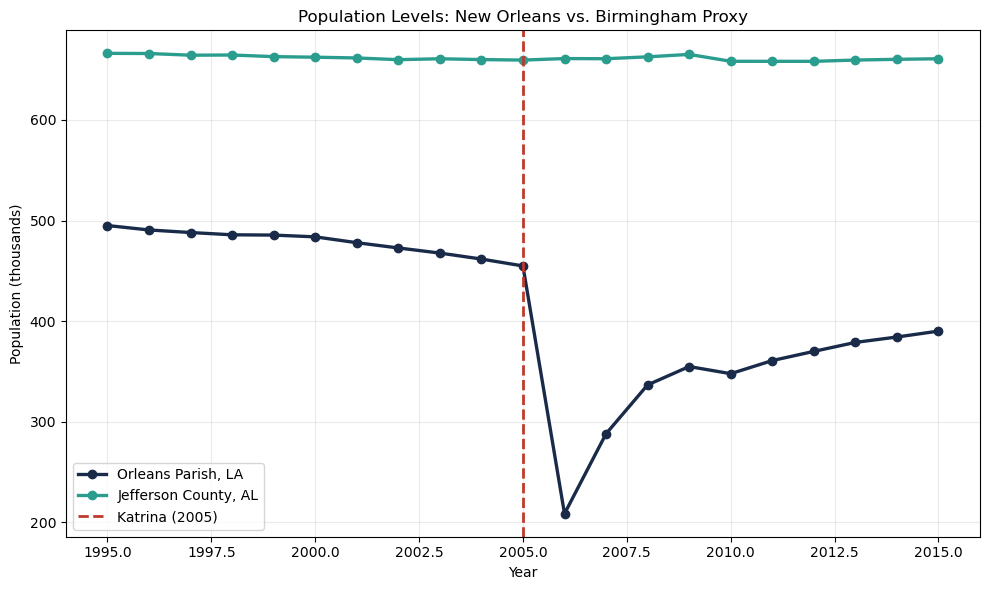

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

for location, color in [('Orleans Parish, LA', NAVY), ('Jefferson County, AL', TEAL)]:
    temp = panel[panel['location'] == location]
    ax.plot(temp['year'], temp['population_k'], marker='o', linewidth=2.4, color=color, label=location)

ax.axvline(2005, color=RED, linestyle='--', linewidth=2, label='Katrina (2005)')
ax.set_title('Population Levels: New Orleans vs. Birmingham Proxy')
ax.set_xlabel('Year')
ax.set_ylabel('Population (thousands)')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(project_root / 'exports' / 'population_levels_birmingham.png', dpi=300, bbox_inches='tight')
plt.show()


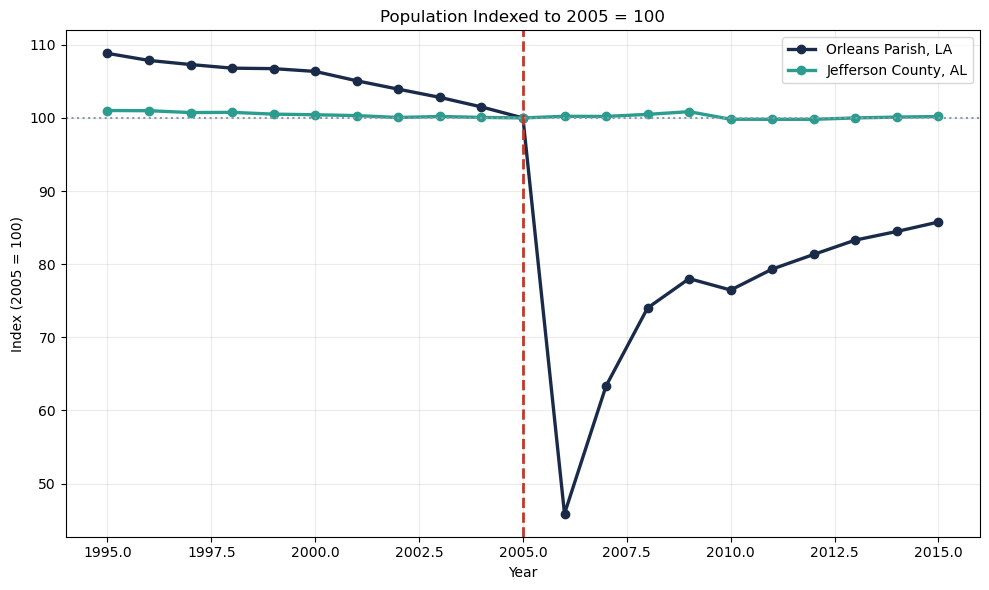

In [9]:
indexed = panel.copy()
indexed['value_2005'] = indexed.groupby('location')['population_k'].transform(lambda s: s.loc[indexed.loc[s.index, 'year'] == 2005].iloc[0])
indexed['index_2005'] = indexed['population_k'] / indexed['value_2005'] * 100

fig, ax = plt.subplots(figsize=(10, 6))
for location, color in [('Orleans Parish, LA', NAVY), ('Jefferson County, AL', TEAL)]:
    temp = indexed[indexed['location'] == location]
    ax.plot(temp['year'], temp['index_2005'], marker='o', linewidth=2.4, color=color, label=location)

ax.axvline(2005, color=RED, linestyle='--', linewidth=2)
ax.axhline(100, color=GRAY, linestyle=':', linewidth=1.5)
ax.set_title('Population Indexed to 2005 = 100')
ax.set_xlabel('Year')
ax.set_ylabel('Index (2005 = 100)')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(project_root / 'exports' / 'population_indexed_birmingham.png', dpi=300, bbox_inches='tight')
plt.show()


**DiD Table**

In [10]:
did_table = (
    panel.groupby(['location', 'post_katrina'])['population_k']
    .mean()
    .reset_index()
    .pivot(index='location', columns='post_katrina', values='population_k')
    .rename(columns={0: 'pre_mean', 1: 'post_mean'})
)
did_table['change'] = did_table['post_mean'] - did_table['pre_mean']

did_effect = did_table.loc['Orleans Parish, LA', 'change'] - did_table.loc['Jefferson County, AL', 'change']

did_table.loc['Difference-in-Differences Effect', 'pre_mean'] = np.nan
did_table.loc['Difference-in-Differences Effect', 'post_mean'] = np.nan
did_table.loc['Difference-in-Differences Effect', 'change'] = did_effect

did_table = did_table.reset_index().rename(columns={'index': 'group'})
did_table.to_csv(project_root / 'exports' / 'did_table_birmingham.csv', index=False)
did_table


post_katrina,location,pre_mean,post_mean,change
0,"Jefferson County, AL",662.483,660.432,-2.051
1,"Orleans Parish, LA",478.513,342.004,-136.510
2,Difference-in-Differences Effect,NaN,NaN,-134.458


**DiD as Regression**

In [11]:
did_model = smf.ols('population_k ~ treated + post_katrina + treated:post_katrina', data=panel).fit(cov_type='HC1')
log_did_model = smf.ols('log_population_k ~ treated + post_katrina + treated:post_katrina', data=panel).fit(cov_type='HC1')

coef_level = did_model.params['treated:post_katrina']
p_level = did_model.pvalues['treated:post_katrina']
coef_log = log_did_model.params['treated:post_katrina']
pct_effect = (np.exp(coef_log) - 1) * 100

results_table = pd.DataFrame({
    'model': ['DiD in levels', 'DiD in logs'],
    'interaction_coef': [coef_level, coef_log],
    'p_value': [p_level, log_did_model.pvalues['treated:post_katrina']],
    'r_squared': [did_model.rsquared, log_did_model.rsquared],
    'interpretation': [
        f'Orleans Parish lost about {coef_level:,.1f} thousand more residents after Katrina than Jefferson County, AL.',
        f'The post-Katrina population level in Orleans Parish was about {pct_effect:,.1f}% lower relative to the control group.'
    ]
})
results_table.to_csv(project_root / 'exports' / 'regression_results_birmingham.csv', index=False)

print(did_model.summary())
print()
print('=' * 90)
print()
print(log_did_model.summary())
print()
print('Key interaction effect (levels):', round(coef_level, 3), 'thousand people')
print('Key interaction effect (logs):', round(coef_log, 4), '=>', round(pct_effect, 2), '%')
results_table


                            OLS Regression Results                            
Dep. Variable:           population_k   R-squared:                       0.962
Model:                            OLS   Adj. R-squared:                  0.959
Method:                 Least Squares   F-statistic:                     845.3
Date:                Mon, 04 May 2026   Prob (F-statistic):           8.17e-35
Time:                        15:02:22   Log-Likelihood:                -197.05
No. Observations:                  42   AIC:                             402.1
Df Residuals:                      38   BIC:                             409.1
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept              662.4829 

,model,interaction_coef,p_value,r_squared,interpretation
0,DiD in levels,-134.458,0.000,0.962,Orleans Parish lost about -134.5 thousand more...
1,DiD in logs,-0.347,0.000,0.905,The post-Katrina population level in Orleans P...


**Parallel Trends Plot**

In [12]:
pre_kat  = panel.query("treated == 1 and post_katrina == 0")["population"].mean()
post_kat = panel.query("treated == 1 and post_katrina == 1")["population"].mean()
ctrl_pre_kat  = panel.query("treated == 0 and post_katrina == 0")["population"].mean()
ctrl_post_kat = panel.query("treated == 0 and post_katrina == 1")["population"].mean()

print(f"Treated   | Before: {pre_kat:.2f}  After: {post_kat:.2f}")
print(f"Control   | Before: {ctrl_pre_kat:.2f}  After: {ctrl_post_kat:.2f}")

Treated   | Before: 478513.18  After: 342003.60
Control   | Before: 662482.91  After: 660431.80


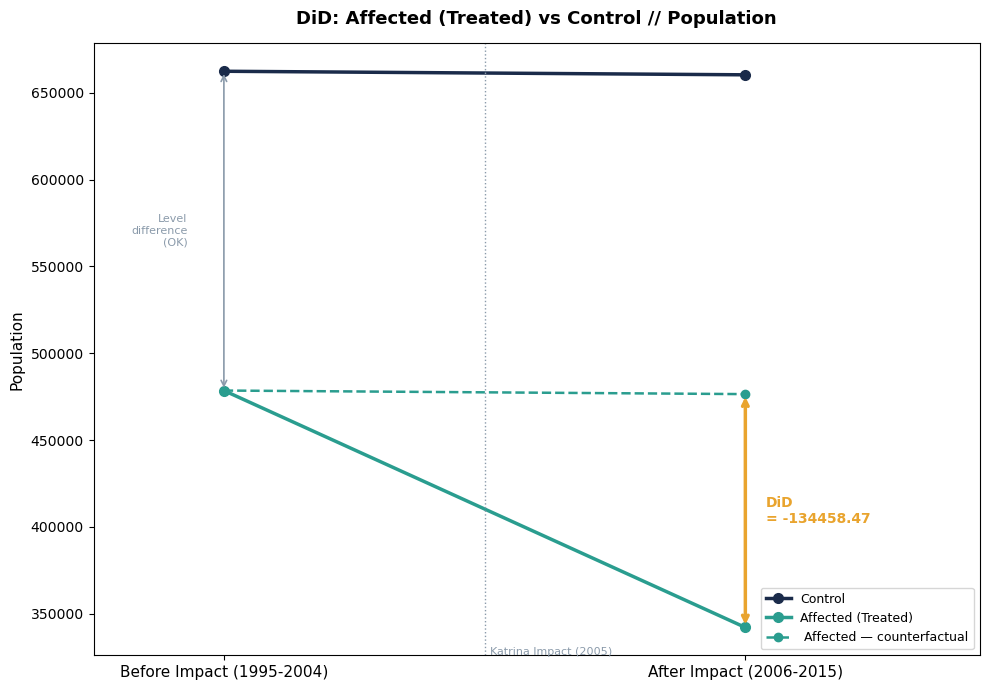

In [13]:
fig, ax1 = plt.subplots(figsize=(10, 7))

treat_cf = pre_kat + (ctrl_post_kat - ctrl_pre_kat)

x = [0, 1]  

ax1.plot(x, [ctrl_pre_kat, ctrl_post_kat], color=NAVY, lw=2.5, marker="o", ms=7, label="Control")
ax1.plot(x, [pre_kat, post_kat], color=TEAL, lw=2.5, marker="o", ms=7, label="Affected (Treated)")
ax1.plot(x, [pre_kat, treat_cf], color=TEAL, lw=1.8, ls="--", marker="o", ms=6,
        label=" Affected — counterfactual")

ax1.annotate("", xy=(1, post_kat), xytext=(1, treat_cf),
            arrowprops=dict(arrowstyle="<->", color=GOLD, lw=2.5))
ax1.text(1.04, (post_kat + treat_cf) / 2,
        f"DiD\n= {post_kat - treat_cf:.2f}",
        color=GOLD, fontsize=10, fontweight="bold", va="center")
ax1.annotate("", xy=(0, pre_kat), xytext=(0, ctrl_pre_kat),
            arrowprops=dict(arrowstyle="<->", color=GRAY, lw=1.2))
ax1.text(-0.07, (pre_kat + ctrl_pre_kat) / 2,
        "Level\ndifference\n(OK)",
        color=GRAY, fontsize=8, ha="right", va="center")
ax1.set_xticks([0, 1])
ax1.set_xticklabels(["Before Impact (1995-2004)" , "After Impact (2006-2015)"], fontsize=11)
ax1.set_ylabel("Population", fontsize=11)
ax1.set_title("DiD: Affected (Treated) vs Control // Population", fontsize=13, fontweight="bold", pad=14)
ax1.set_xlim(-0.25, 1.45)
ax1.legend(loc="lower right", fontsize=9)
ax1.axvline(x=0.5, color=GRAY, lw=1, ls="dotted")
ax1.text(0.51, ax1.get_ylim()[0] - 0.2, "Katrina Impact (2005)", color=GRAY, fontsize=8)

plt.tight_layout()

plt.savefig(project_root / 'exports' / 'kat_parallel_trends.png', dpi=300, bbox_inches='tight')
plt.show()

**Event Study**

This section builds an event-study-style visualization by comparing the annual gap between Orleans Parish and Jefferson County, then re-centering that gap to zero in 2005. It is a descriptive way to show how sharply the relationship changes after Katrina.


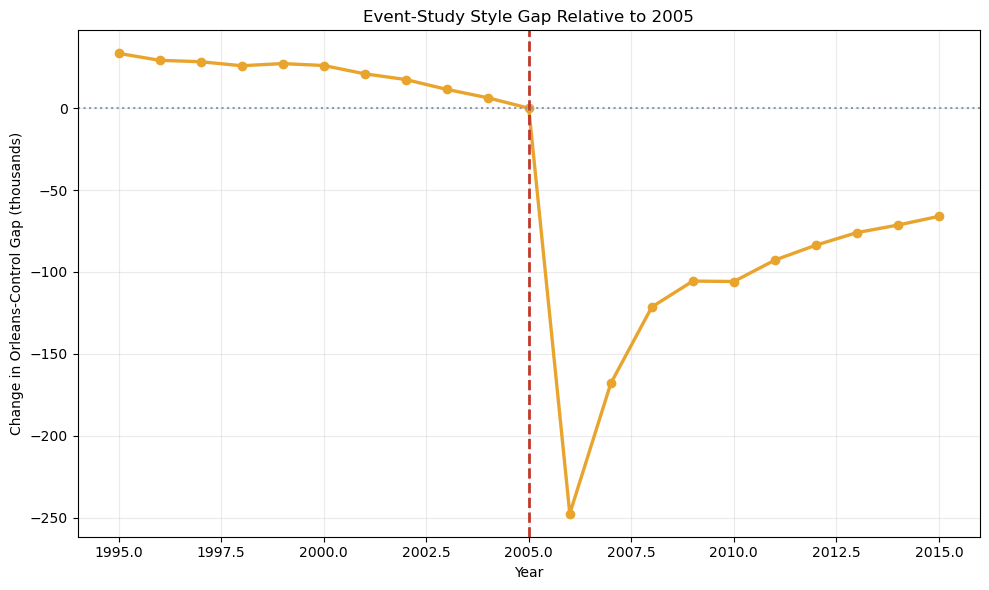

2005 Orleans population: 454.845 thousand
2006 Orleans population: 208.653 thousand
Latest Orleans population: 390.094 thousand
Immediate one-year drop: -54.13 %
Recovered share of 2005 level: 85.76 %


In [14]:
wide = panel.pivot(index='year', columns='location', values='population_k').reset_index()
wide['gap_orleans_minus_control'] = wide['Orleans Parish, LA'] - wide['Jefferson County, AL']
gap_2005 = wide.loc[wide['year'] == 2005, 'gap_orleans_minus_control'].iloc[0]
wide['event_effect_vs_2005'] = wide['gap_orleans_minus_control'] - gap_2005
wide.to_csv(project_root / 'exports' / 'event_study_birmingham.csv', index=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(wide['year'], wide['event_effect_vs_2005'], color=GOLD, marker='o', linewidth=2.4)
ax.axvline(2005, color=RED, linestyle='--', linewidth=2)
ax.axhline(0, color=GRAY, linestyle=':', linewidth=1.5)
ax.set_title('Event-Study Style Gap Relative to 2005')
ax.set_xlabel('Year')
ax.set_ylabel('Change in Orleans-Control Gap (thousands)')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(project_root / 'exports' / 'event_study_birmingham.png', dpi=300, bbox_inches='tight')
plt.show()

recovery_2005 = panel.query("location == 'Orleans Parish, LA' and year == 2005")['population_k'].iloc[0]
recovery_2006 = panel.query("location == 'Orleans Parish, LA' and year == 2006")['population_k'].iloc[0]
recovery_latest = panel.query("location == 'Orleans Parish, LA'")['population_k'].iloc[-1]

print('2005 Orleans population:', round(recovery_2005, 3), 'thousand')
print('2006 Orleans population:', round(recovery_2006, 3), 'thousand')
print('Latest Orleans population:', round(recovery_latest, 3), 'thousand')
print('Immediate one-year drop:', round((recovery_2006 / recovery_2005 - 1) * 100, 2), '%')
print('Recovered share of 2005 level:', round((recovery_latest / recovery_2005) * 100, 2), '%')


**Exporting Files**

This notebook exports clean data, summary statistics, DiD tables, regression results, and figures to the `exports/` folder so they can be reused in the written report and presentation.


In [15]:
export_files = sorted(str(path.relative_to(project_root)) for path in (project_root / 'exports').glob('*'))
print('Exported files:')
for file_name in export_files:
    print('-', file_name)


Exported files:
- exports/did_table_birmingham.csv
- exports/event_study_birmingham.csv
- exports/event_study_birmingham.png
- exports/kat_parallel_trends.png
- exports/population_indexed_birmingham.png
- exports/population_levels_birmingham.png
- exports/regression_results_birmingham.csv
- exports/summary_stats_birmingham.csv
